# Log in

In [ ]:
import qnexus as qnx
qnx.login()

In [ ]:
project_name = "Leakage detection"
project = qnx.projects.get_or_create(name=project_name)
qnx.context.set_active_project(project)

# Circuit creation

In [ ]:
from anszats import Angular2Encoder
import numpy as np
from pathlib import Path
from pytket.circuit import Circuit, OpType
from pytket.passes import SynthesiseTK, AutoRebase, AutoSquash, RemoveRedundancies, RemovePhaseOps

from pytket.circuit.display import render_circuit_jupyter as draw

In [ ]:
ropes_f=Path('ropes_v2.npy') 
encoder=Angular2Encoder
encoder_scale= 2.4/np.pi
ropes = np.load(ropes_f, allow_pickle=True) # load rope embeddings

In [ ]:
n_q = 20 # number of target qubits in the Angular encoding 

In [ ]:
len(ropes[0,0,:]) # check dimension

1024

In [8]:
encoder_obj = encoder(n=len(ropes[0,0,:]), q=n_q, scale=encoder_scale)

In [ ]:
# form 16 quantum circuits and apply optimization passes
indices = range(len(ropes))
circuits = []

gates_all = {OpType.Rz, OpType.PhasedX, OpType.ZZPhase}
gates_single = {OpType.Rz, OpType.PhasedX}

for i in range(16):
    params = ropes[i, :, :]
    circ0 = encoder_obj.dispatch(params[0, :])
    circ1 = encoder_obj.dispatch(params[1, :])
    circuit = circ0 >> circ1.dagger()
    SynthesiseTK().apply(circuit) 
    AutoRebase(gates_all).apply(circuit)
    AutoSquash(gates_single).apply(circuit)
    RemoveRedundancies().apply(circuit)
    RemovePhaseOps().apply(circuit)
    # circuit.measure_all()
    circuits.append(circuit)

print(f'Created {len(circuits)} circuits.')

Created 16 circuits.


In [14]:
# draw(circuits[0])
# circuits[0]

In [ ]:
# upload circuits to Quantinuum Nexus
circuit_refs = []

for i, circ in enumerate(circuits):
    circuit_ref = qnx.circuits.upload(
        circ, 
        name=f"Leakage-prog{i}-{n_q}q"
    )
    circuit_refs.append(circuit_ref)

In [ ]:
circuit_refs

# Convertion to guppy

In [10]:
from guppylang import guppy

In [11]:
helios_funcs = [guppy.load_pytket(f"helios_func_{i}", circuits[i]) for i in range(len(circuits))]

In [ ]:
helios_funcs

In [ ]:
from guppylang.std.quantum import measure_array, discard_array, qubit
from guppylang.std.builtins import array, comptime, result
from guppylang.std.qsystem import measure_leaked

In [ ]:
# Create HUGR binaries
helios_binaries = []

for helios_func in helios_funcs:
  @guppy
  def guppy_func() -> None:
    qs = array(qubit() for _ in range(comptime(n_q)))
    helios_func(qs)
    # result("c", measure_array(qs))

    # Initialize an array to hold our ternary (0, 1, 2) results
    # We use a loop that Guppy can compile into the circuit
    c_results = array(0 for _ in range(comptime(n_q)))

    idx = 0
    # This loop CONSUMES the qubits in 'qs' one by one
    for q in qs:
        m = measure_leaked(q)

        # 1. Immediately consume 'm' to get an Option[bool]
        # This satisfies the compiler's requirement to consume the resource.
        res_opt = m.to_result()

        # 2. Branch on the Option
        if res_opt.is_some():
            # If it didn't leak, unwrap the boolean (True=1, False=0)
            c_results[idx] = 1 if res_opt.unwrap() else 0
        else:
            # If it leaked, the Option is None
            c_results[idx] = 2

        idx += 1

    result("c", c_results)

  helios_binary = guppy_func.compile()
  helios_binaries.append(helios_binary)

In [ ]:
# Upload HUGRs
refs_hugr = []

for i, helios_binary in enumerate(helios_binaries):
    ref_hugr = qnx.hugr.upload(
        helios_binary, 
        name=f"Helios-{n_q}q-leakage-circ{i}"
    )
    refs_hugr.append(ref_hugr)

In [ ]:
refs_hugr

# Download hugr (if needed)

In [ ]:
# n_q = 20

# hugr_progs_names = [f"Helios-{n_q}q-leakage-circ{i}" for i in range(16)] 
# hugr_progs = [qnx.hugr.get(name = n) for n in hugr_progs_names[0:16]

In [26]:
hugr_progs = refs_hugr

In [27]:
len(hugr_progs)

16

# Cost estimation

In [81]:
n_shots_1_sim = 200

prediction = qnx.hugr.cost_confidence(
    programs=hugr_progs[0:1],
    n_shots=[n_shots_1_sim] * 1
)
prediction

[(245.0, 95.0)]

# Config creation

In [ ]:
import numpy as np

# system_name="Helios-1"    # Real
system_name="Helios-1E-lite"  # Emulator lite

config = qnx.models.HeliosConfig(
    system_name=system_name,
    max_cost=prediction[0][0]+1.0,
    emulator_config=qnx.models.HeliosEmulatorConfig( # no need for real Helios-1
        n_qubits=n_q, 
        simulator=qnx.models.StatevectorSimulator()
    )
)

# Launching jobs

In [ ]:
import numpy as np

n_shots_1_sim = 200

[qnx.start_execute_job(
    programs=hugr_progs[i:i+1],
    n_shots=[n_shots_1_sim]*1,
    backend_config=config,
    name=f"Helios-{n_q}q-leakage-prog{i}",
) for i in range(16)]

In [ ]:
# qnx.jobs.wait_for(result_ref)

# Loading results (single job)

In [ ]:
n_q = 20

system_name="Helios-1E-lite"

In [ ]:
# GET JOBS BY NAME IF NEEDED

jobs_refs = [qnx.client.jobs.get(
    name=f"Helios-{n_q}q-leakage-prog{i}"
) for i in range(16)]

In [43]:
jobs_results = [qnx.jobs.results(ref, allow_incomplete=True) for ref in jobs_refs]

In [8]:
jobs_results[0][0]

ExecutionResultRef(id=UUID('3ca5ce1e-fe57-4b02-af1e-481b0732335b'), annotations=Annotations(name='Helios-20q-leakage-emulation-lite-prog0', description='', properties=OrderedDict(), created=datetime.datetime(2026, 4, 29, 8, 0, 7, 675476, tzinfo=TzInfo(UTC)), modified=datetime.datetime(2026, 4, 29, 8, 7, 3, 284347, tzinfo=TzInfo(UTC))), project=ProjectRef(id=UUID('53d3f53e-d0a1-4e16-9f10-806fd74bd1fe'), annotations=Annotations(name='Leakage detection', description=None, properties=OrderedDict(), created=datetime.datetime(2026, 4, 29, 5, 51, 26, 83684, tzinfo=TzInfo(UTC)), modified=datetime.datetime(2026, 4, 29, 5, 51, 26, 83684, tzinfo=TzInfo(UTC))), contents_modified=datetime.datetime(2026, 4, 29, 8, 17, 34, 94545, tzinfo=TzInfo(UTC)), archived=False, type='ProjectRef'), result_type=<ResultType.QSYS: 'QSYS'>, cost=None, last_status_detail=JobStatus(status=<JobStatusEnum.COMPLETED: 'COMPLETED'>, message='Circuit has completed.', error_detail=None, completed_time=datetime.datetime(2026, 

In [ ]:
# Process results 
# There are three values possible in measuring a single qubit: 0,1,2. The value 2 means there was a leak, 
# while 0 or 1 indicates the measurement result without a leak. 

# Label `good` means we've got the all zero zero without any leaks; 
# label `bad` means we've got not the all zero state without any leaks. 
# Label `leakage_good` means we've got the all zero state with some leaked qubits; 
# label `leakage_bad` means we've got not the all zero state with some leaked qubits. 

from collections import Counter
from guppylang.emulator import EmulatorResult

def get_counts(shots: EmulatorResult) -> Counter[str]:
    """Counter treating all results from a shot as entries in a single bitstring.
    Returns "leakage" if any qubit in the register was in the leaked state (2).
    """
    counter_list = []
    for shot in shots:
        for e in shot:
            # e[1] is the array of measurement results (e.g., [0, 1, 2, 0])
            results = e[1]

            # Check if the leakage value (2) is present in the results
            if 2 in results:
                if 1 in results:
                    bitstring = "leakage_bad"
                else:
                    bitstring = "leakage_good"
            else:
                # bitstring = "".join(str(k) for k in results)
                if 1 in results:
                    bitstring = "bad"
                else: 
                    bitstring = "good"

            counter_list.append(bitstring)

    return Counter(counter_list)

In [ ]:
len(jobs_results) # recheck the number of circuits

16

In [ ]:
# assert len(job_results) == len(refs_hugr)

counts_good = [0]*len(jobs_results)
counts_bad = [0]*len(jobs_results)
counts_leakage_good = [0]*len(jobs_results)
counts_leakage_bad = [0]*len(jobs_results)

# n_q = 20

for i in range(len(jobs_results)):
    result = jobs_results[i][0].download_result()
    print(len(result)) # shot the number of shots completed
    cnts = get_counts(result)
    counts_good[i] = cnts.get("good",0)
    counts_bad[i] = cnts.get("bad",0)
    counts_leakage_good[i] = cnts.get("leakage_good",0)
    counts_leakage_bad[i] = cnts.get("leakage_bad",0)


200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200


In [45]:
print(counts_good)
print(counts_bad)
print(counts_leakage_good)
print(counts_leakage_bad)

[101, 90, 92, 104, 75, 73, 73, 50, 71, 58, 49, 47, 33, 33, 17, 24]
[57, 71, 72, 62, 78, 93, 98, 106, 105, 111, 110, 116, 138, 134, 145, 144]
[7, 6, 5, 3, 5, 7, 3, 4, 2, 2, 2, 3, 2, 0, 2, 3]
[35, 33, 31, 31, 42, 27, 26, 40, 22, 29, 39, 34, 27, 33, 36, 29]


In [93]:
sum(counts_leakage_bad+counts_leakage_good)/16/200

0.178125

In [ ]:
# Compute fidelitites based on the occurrence of the all zero state
fids = [(counts_good[i]+counts_leakage_good[i]) / (counts_good[i]+counts_leakage_good[i]+counts_bad[i]+counts_leakage_bad[i]) for i in range(16)]

In [47]:
fids

[0.54,
 0.48,
 0.485,
 0.535,
 0.4,
 0.4,
 0.38,
 0.27,
 0.365,
 0.3,
 0.255,
 0.25,
 0.175,
 0.165,
 0.095,
 0.135]

# Plotting

In [ ]:
fidelities = [0.4575, 0.4325, 0.3925, 0.4025, 0.33, 0.3125, 0.2975, 0.3075, 0.27, 0.2237, 0.21, 0.18, 0.13, 0.1675, 0.1075, 0.1575]
LD_values = [199, 651, 1321, 2133, 3139, 4253, 5427, 6729, 8154, 9486, 11025, 12721, 14931, 15991, 17930, 19634]

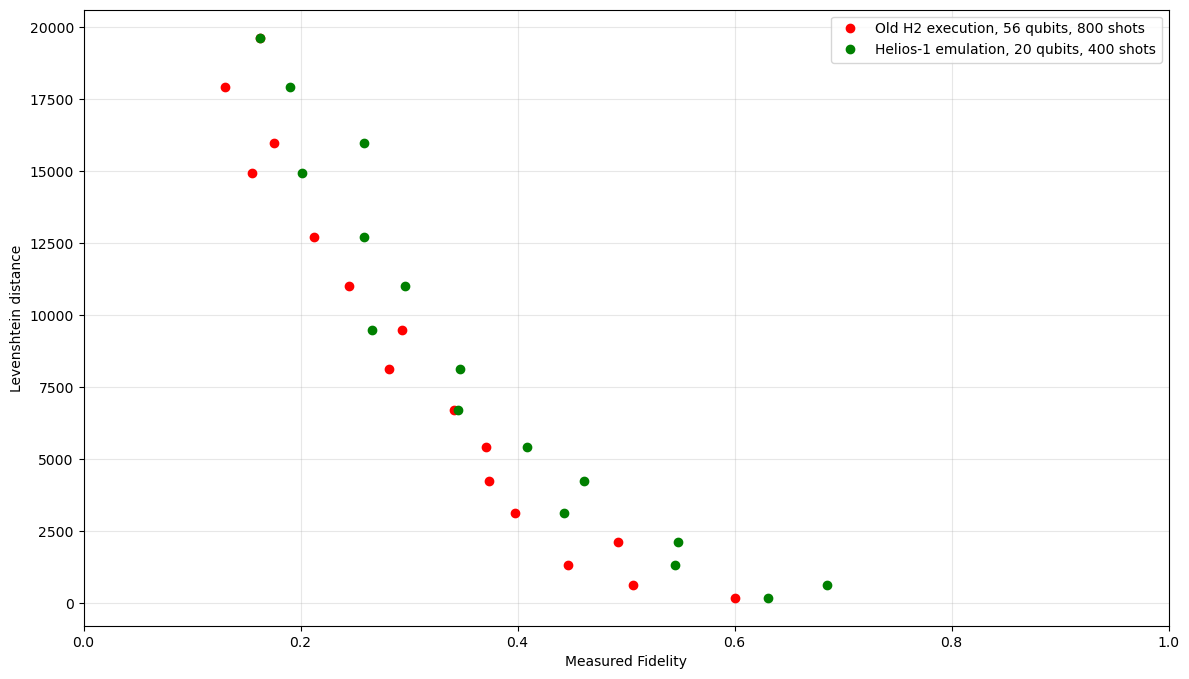

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fidelities1 = [0.6, 0.50625, 0.44625, 0.4925, 0.3975, 0.37375, 0.37125, 0.34125, 0.28125, 0.29375, 0.245, 0.2125, 0.155, 0.175, 0.13, 0.1625]
fidelities2 = [0.525, 0.46499999999999997, 0.43666666666666665, 0.405, 0.365, 0.3125, 0.2975, 0.3, 0.32, 0.275, 0.18318181818181817, 0.2375, 0.15500000000000003, 0.1625, 0.15000000000000002, 0.1275]
fidelities3 = [0.29, 0.35, 0.42, 0.275, 0.27, 0.26, 0.25, 0.235, 0.25, 0.235, 0.205, 0.195, 0.13, 0.135, 0.085, 0.1]
distances = [199, 651, 1321, 2133, 3139, 4253, 5427, 6729, 8154, 9486, 11025, 12721, 14931, 15991, 17930, 19634]

# ----------------------------------------
#  PLOT
# ----------------------------------------
plt.figure(figsize=(14,8))
plt.xlim(0, 1)

plt.errorbar(fidelities1, distances, fmt='o', color='red',
             label=f"Old H2 execution, 56 qubits, 800 shots")

# plt.errorbar(fidelities2, distances, fmt='o', color='blue',
             # label=f"Helios-1 execution, 98 qubits, 400 shots")

# plt.errorbar(fidelities3, distances, fmt='o', color='green',
             # label=f"New H2 execution, 56 qubits, 200 shots")

plt.xlabel("Measured Fidelity")
plt.ylabel("Levenshtein distance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Check environment 
import platform
import sys
import os

def versioninfo():
    print(f"Python Version: {sys.version.split()[0]}")
    print(f"Platform: {platform.platform()}")
    print(f"Processor: {platform.processor()}")
    print(f"Architecture: {platform.architecture()[0]}")
    print(f"Machine: {platform.machine()}")
    print(f"CPU Cores: {os.cpu_count()} (logical)")
    # Check for Free-threaded Python (New in 3.13+)
    if hasattr(sys, '_is_gil_enabled'):
        status = "Disabled" if not sys._is_gil_enabled() else "Enabled"
        print(f"GIL Status: {status}")

versioninfo()

Python Version: 3.11.10
Platform: Linux-6.12.68-92.122.amzn2023.x86_64-x86_64-with-glibc2.39
Processor: x86_64
Architecture: 64bit
Machine: x86_64
CPU Cores: 2 (logical)
